# Appendix Deep-Dive: Cancellation Classification Analysis

This notebook contains deeper diagnostics and visualization details for thesis appendix material.

## Scope

- Extended temporal diagnostics
- Ranking and threshold diagnostics
- Grouped feature-importance stability
- CV distribution analysis (rolling-origin vs stratified k-fold)
- Full 5-model benchmark evidence tables

In [1]:
from src.eval.notebook_utils import setup_plotting
PLOT_CFG = setup_plotting()
FIG_DIR = PLOT_CFG["fig_dir"]

In [2]:
from src.eval.notebook_utils import load_analysis_context
ctx = load_analysis_context()

## Figure 1. Monthly Trend + 3-Month Rolling Mean + Booking Volume + Split Regimes

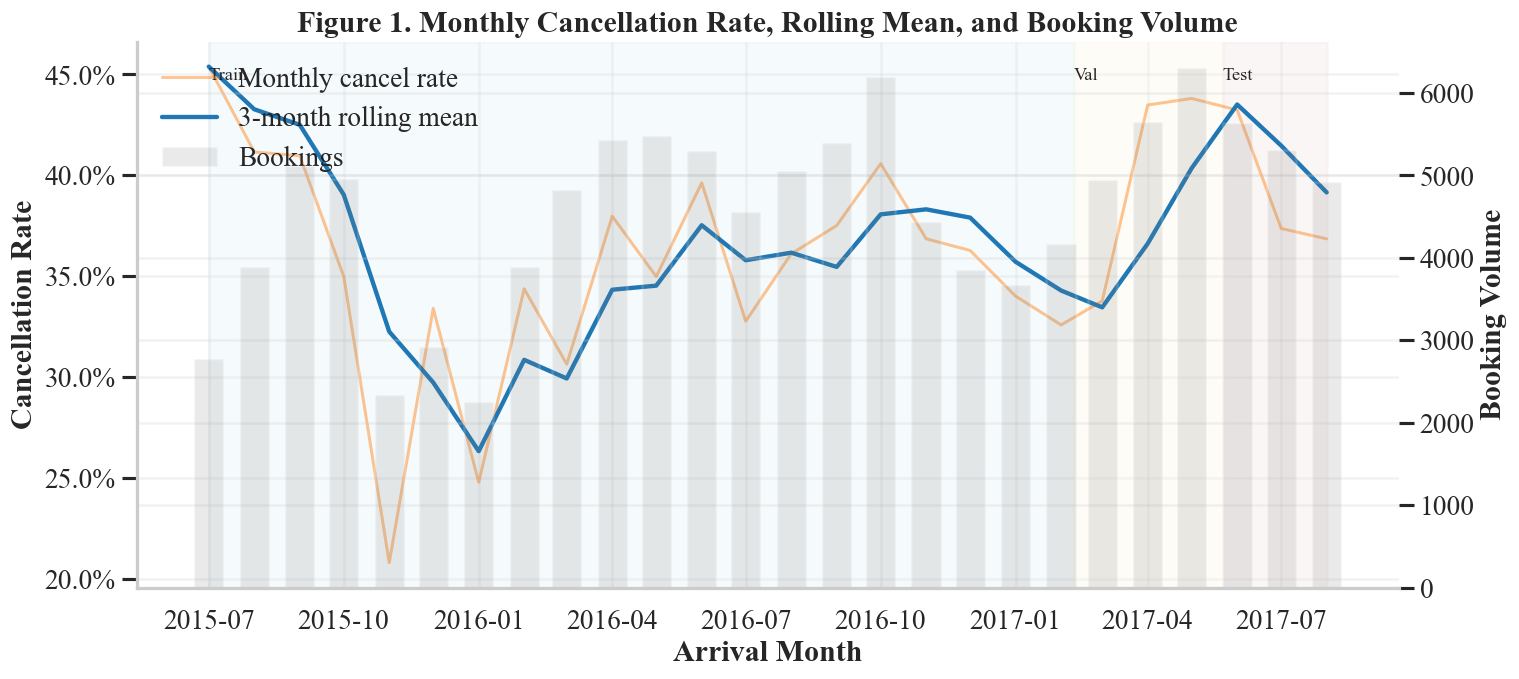

In [3]:
from src.eval.notebook_utils import plot_monthly_trend
plot_monthly_trend(ctx, FIG_DIR, fig_no=1)

**Key Takeaway:** Seasonal changes and split-regime transitions are visible and support time-aware evaluation decisions.

## Figure 2. Ranked Dumbbell Plot (ROC-AUC vs PR-AUC)

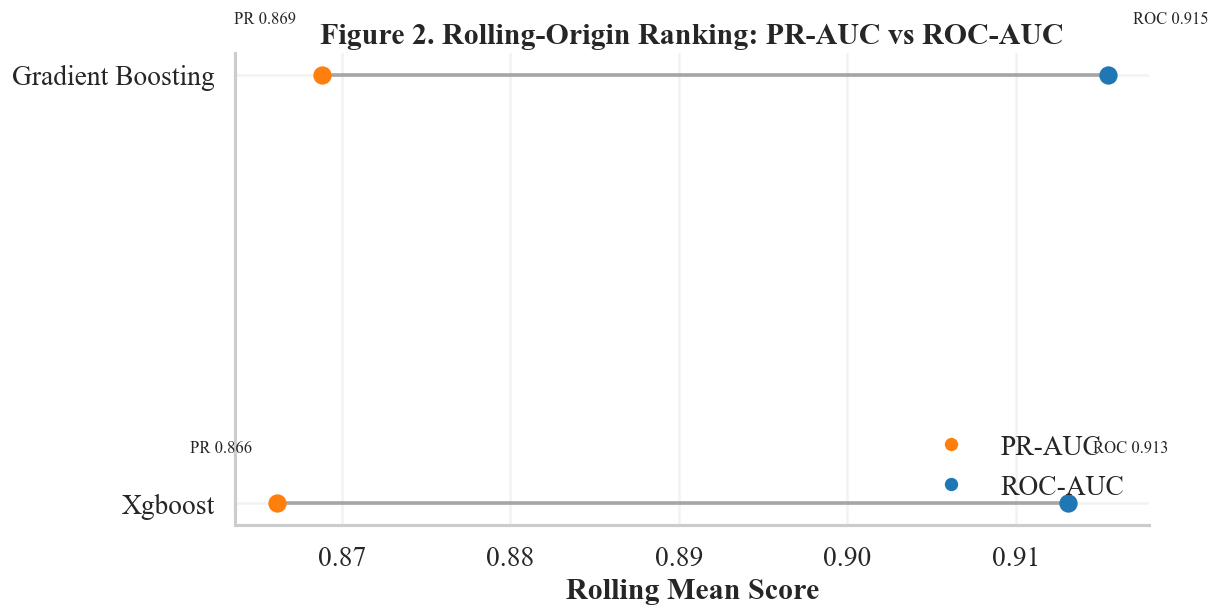

In [4]:
from src.eval.notebook_utils import plot_model_dumbbell
plot_model_dumbbell(ctx, FIG_DIR, fig_no=2)

**Key Takeaway:** The dumbbell view shows both selection metrics jointly, making model ranking transparent.

## Figure 3. Precision-Recall with Iso-F1 Guides and Baseline Prevalence

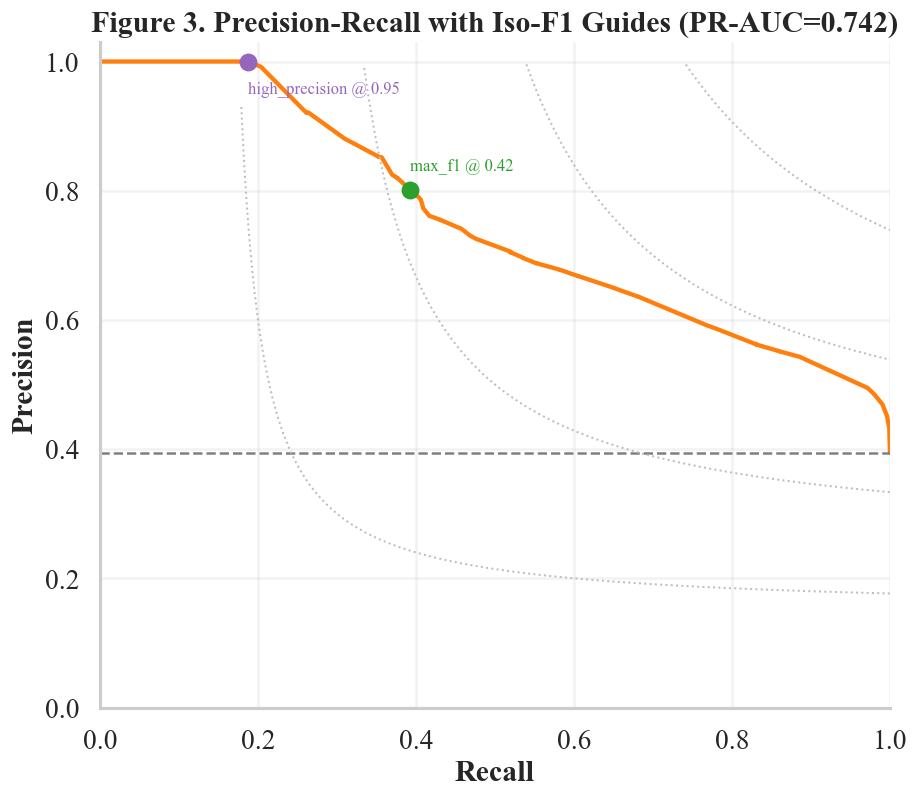

In [5]:
from src.eval.notebook_utils import plot_pr_isof1
plot_pr_isof1(ctx, FIG_DIR, fig_no=3)

**Key Takeaway:** Iso-F1 guides make operating-point tradeoffs interpretable for policy selection.

## Figure 4. Threshold Profile: Precision/Recall/F1/Positive-Rate + Constraints

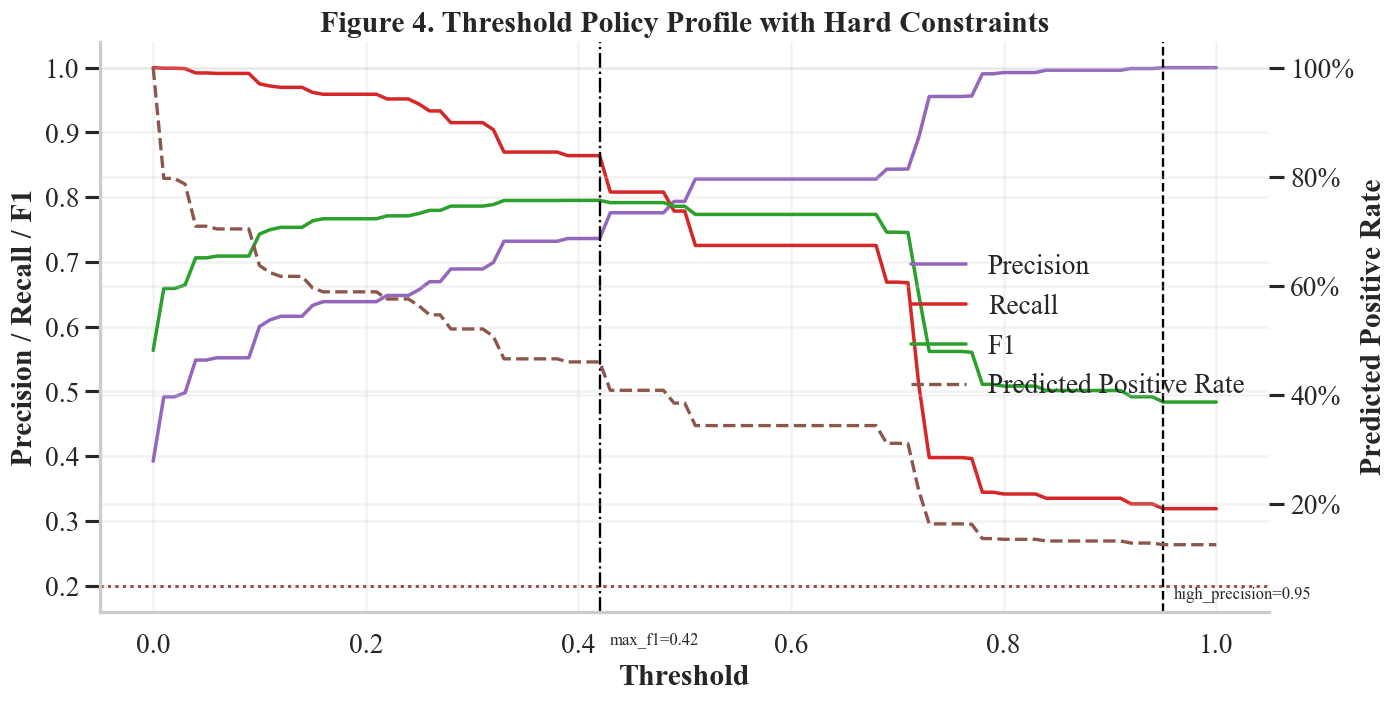

In [6]:
from src.eval.notebook_utils import plot_threshold_diagnostics
plot_threshold_diagnostics(ctx, FIG_DIR, fig_no=4)

**Key Takeaway:** Constraint-aware threshold plots support reproducible policy justification in thesis text.

## Figure 5. Calibration Deep-Dive (Reliability + Probability Histogram)

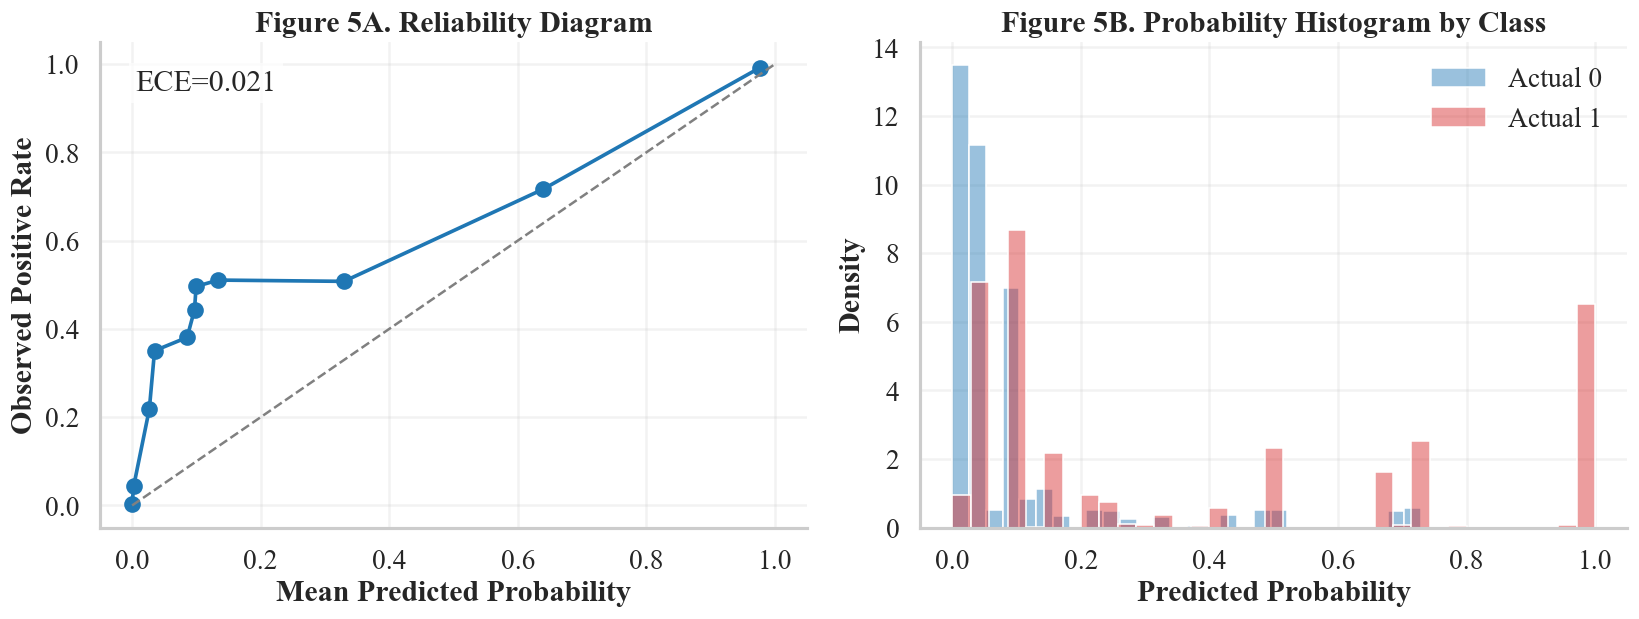

In [7]:
from src.eval.notebook_utils import plot_calibration_deep
plot_calibration_deep(ctx, FIG_DIR, fig_no=5)

**Key Takeaway:** Calibration quality is visible both in reliability alignment and class-probability overlap.

## Figures 6-7. Grouped Permutation Importance (Mean + 95% CI) and Stability

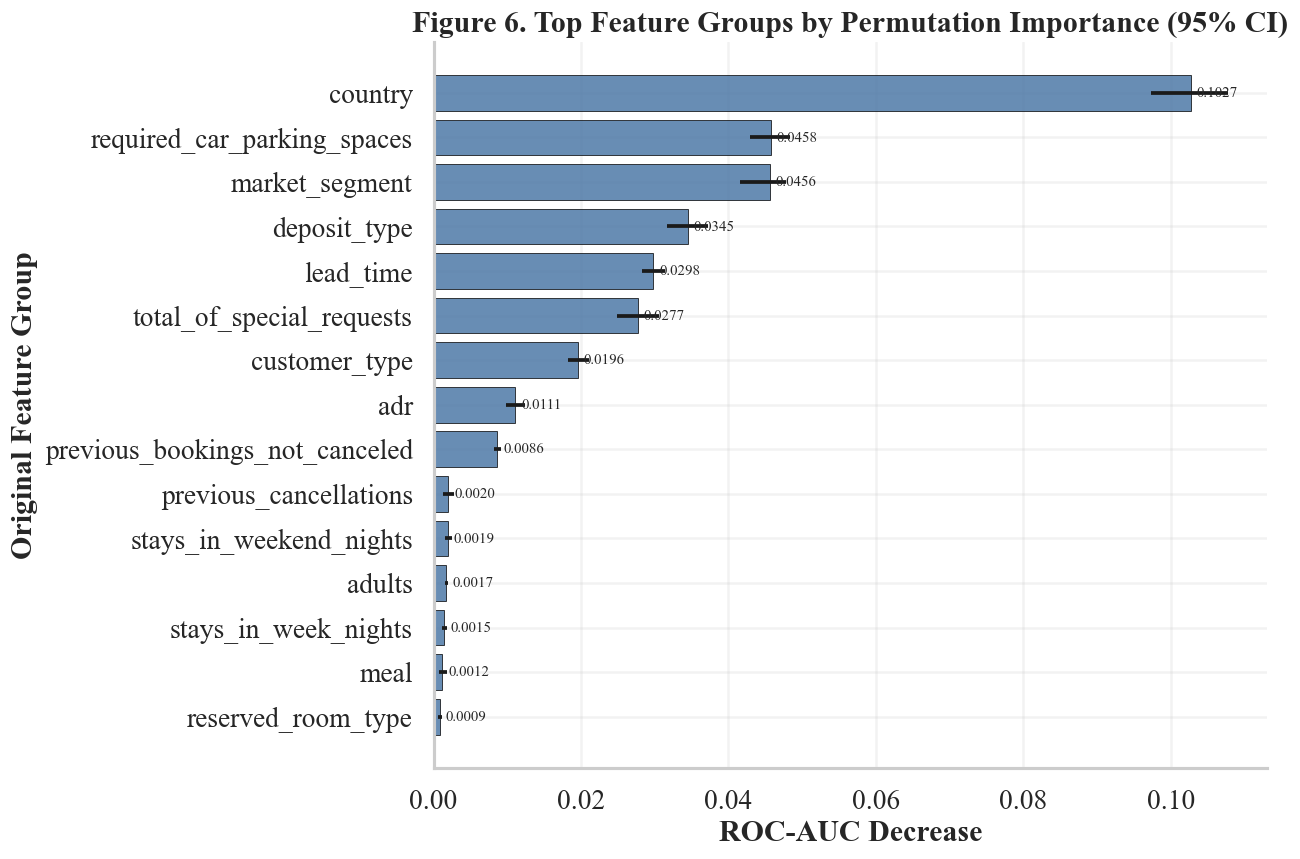

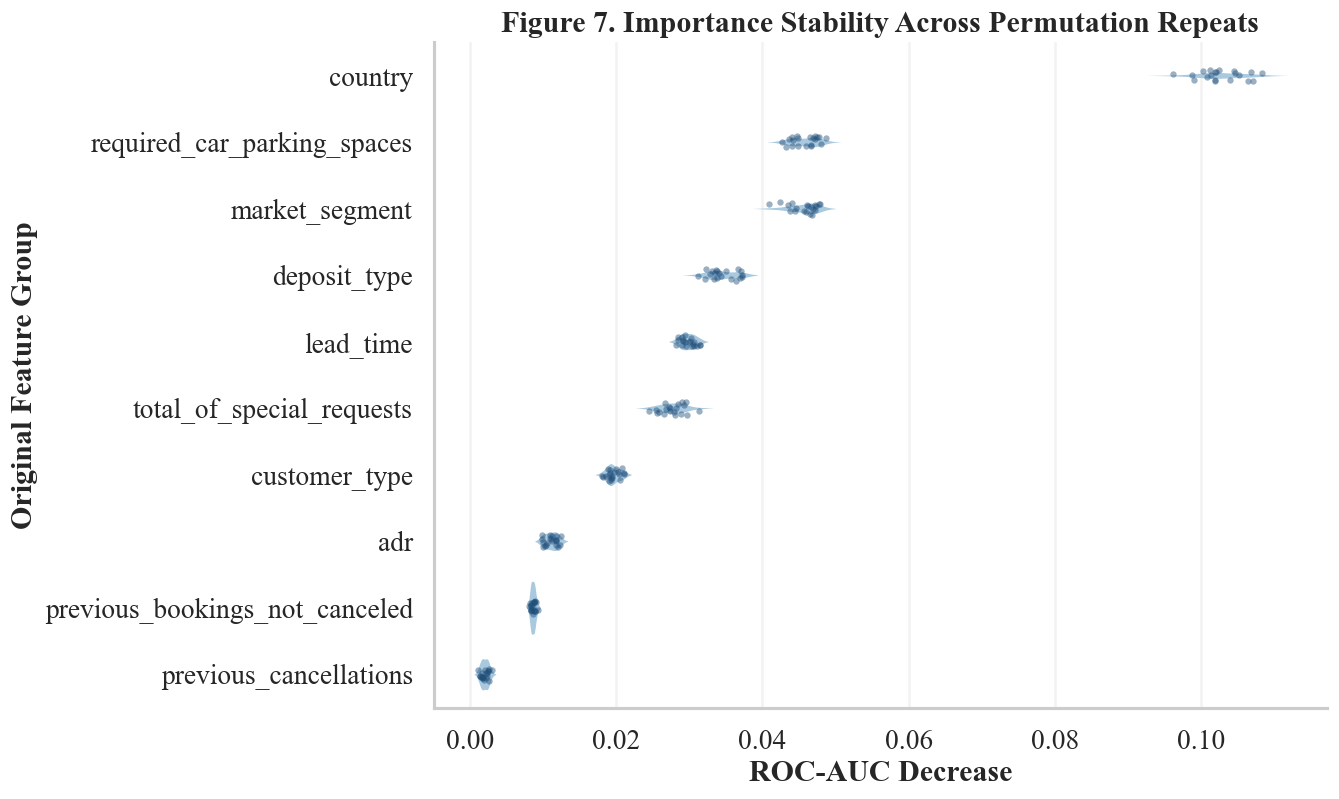

,mean_importance,std_importance,ci_low,ci_high
country,0.102724,0.003105,0.097375,0.107696
required_car_parking_spaces,0.045756,0.001782,0.042875,0.048330
market_segment,0.045580,0.001903,0.041597,0.047797
deposit_type,0.034510,0.001887,0.031610,0.037203
lead_time,0.029801,0.000963,0.028330,0.031439
total_of_special_requests,0.027667,0.001684,0.024922,0.030531
customer_type,0.019567,0.000868,0.018162,0.021099
adr,0.011090,0.000842,0.009854,0.012370
previous_bookings_not_canceled,0.008617,0.000308,0.008156,0.009191
previous_cancellations,0.001998,0.000497,0.001221,0.002786


In [8]:
from src.eval.notebook_utils import plot_grouped_permutation
group_stats, grouped_repeat = plot_grouped_permutation(ctx, FIG_DIR, fig_no_start=6)
group_stats.head(15)

**Key Takeaway:** Aggregating one-hot fragments back to original feature groups improves interpretability and stability reporting.

## Figure 8. CV Distribution Comparison (Violin + Strip Overlay)

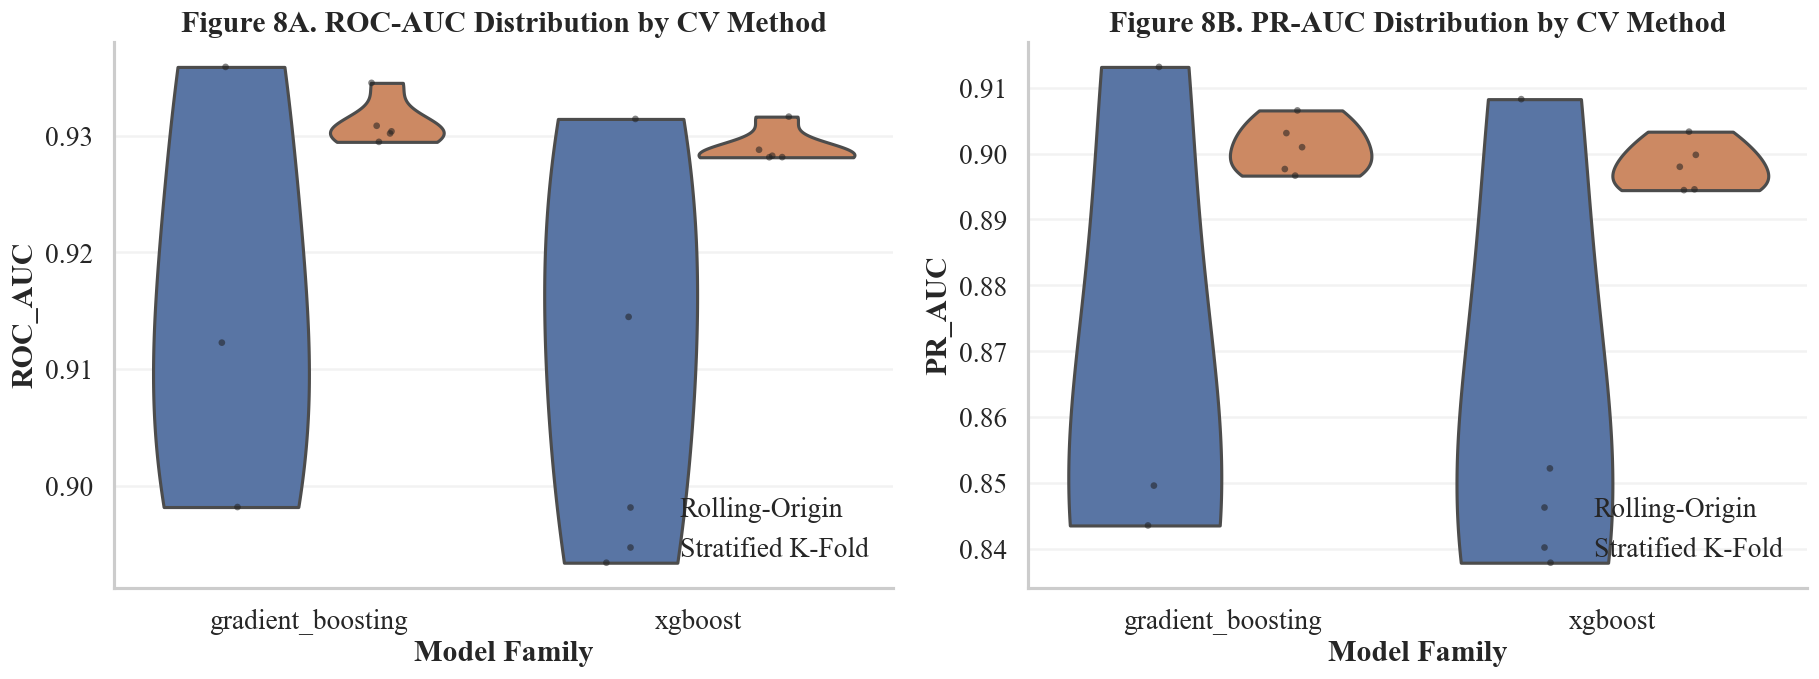

,model_family,roc_auc,pr_auc,method,fold
0,gradient_boosting,0.935910,0.913142,Rolling-Origin,NaN
1,gradient_boosting,0.898178,0.843582,Rolling-Origin,NaN
2,gradient_boosting,0.912271,0.849630,Rolling-Origin,NaN
3,xgboost,0.931451,0.908254,Rolling-Origin,NaN
4,xgboost,0.893404,0.837931,Rolling-Origin,NaN


In [9]:
from src.eval.notebook_utils import plot_cv_violin_strip
cv_compare = plot_cv_violin_strip(ctx, FIG_DIR, fig_no=8, sample_cap=25000)
cv_compare.head()

**Key Takeaway:** Distribution plots show variance directly and clarify method differences between rolling-origin and stratified CV.

## Figure 9. Benchmark Heatmap (Max-F1 Policy Metrics Across 5 Models)

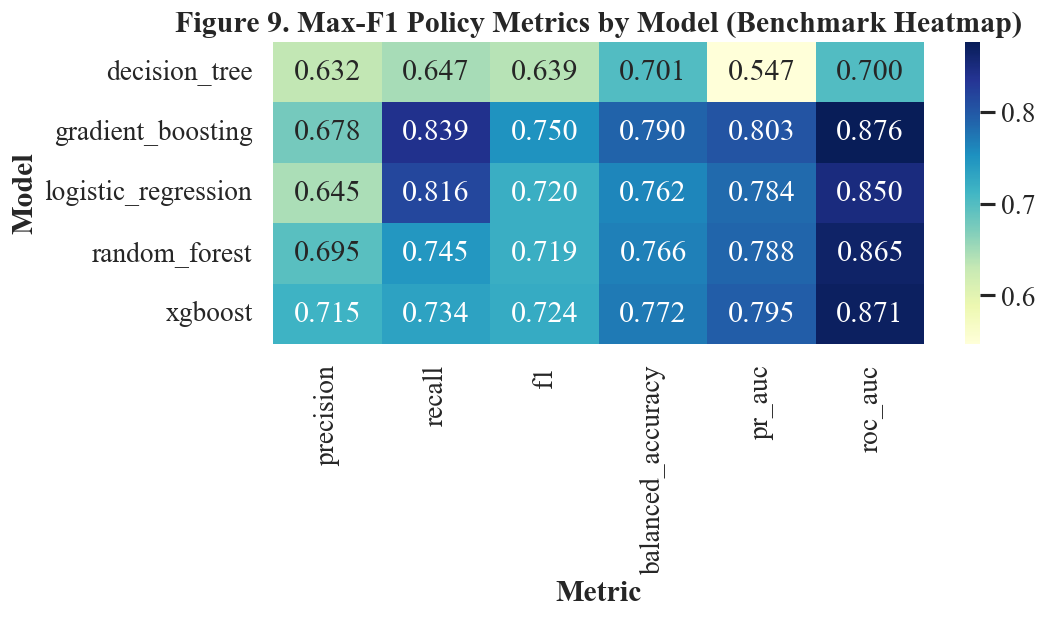

In [10]:
from src.eval.notebook_utils import plot_benchmark_threshold_heatmap
plot_benchmark_threshold_heatmap(ctx, FIG_DIR, fig_no=9)

**Key Takeaway:** One heatmap shows cross-model strengths and weaknesses under the same threshold policy.

## Figure 10. Benchmark Cost vs Performance

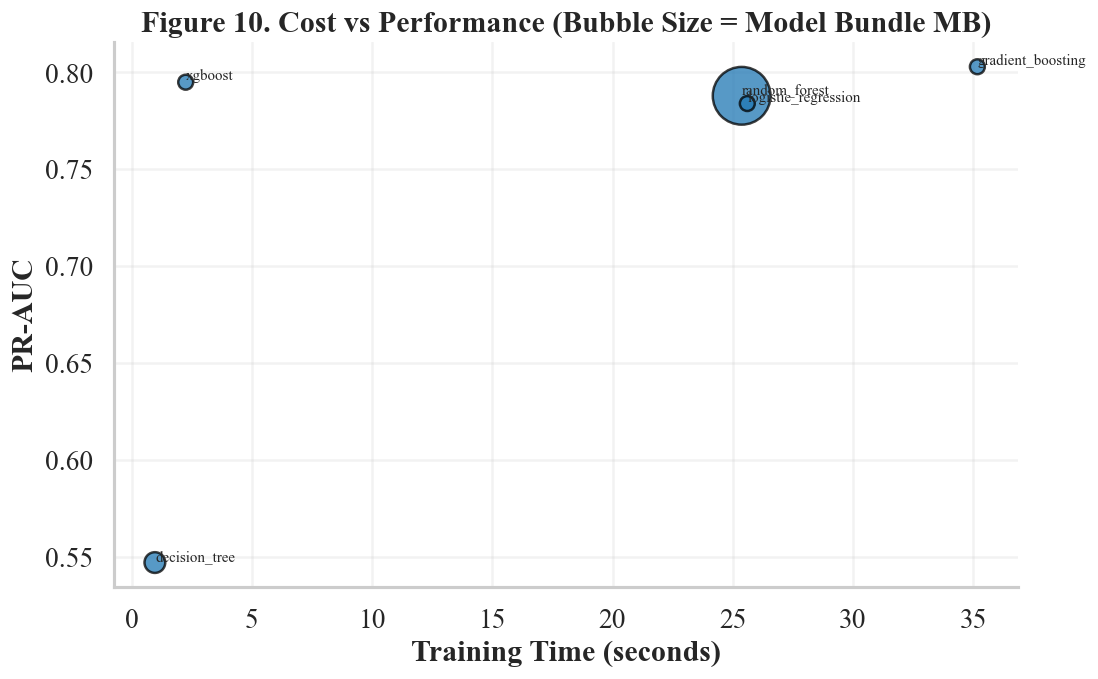

,model,roc_auc,pr_auc,brier_score,ece,fit_seconds,predict_seconds,bundle_size_mb,n_rows_train,n_rows_test
0,gradient_boosting,0.876029,0.802888,0.139446,0.021070,35.174602,0.062363,0.494126,83573,17909
1,xgboost,0.870638,0.794906,0.143205,0.029076,2.242064,0.111306,0.270532,83573,17909
2,random_forest,0.865112,0.787894,0.145597,0.026828,25.368885,1.764505,481.473672,83573,17909
3,logistic_regression,0.850148,0.783885,0.153600,0.026200,25.604711,0.006019,0.067567,83573,17909
4,decision_tree,0.700116,0.546886,0.203966,0.055905,0.960608,0.010166,1.289834,83573,17909


In [11]:
from src.eval.notebook_utils import plot_benchmark_cost_vs_performance
benchmark_cost_perf = plot_benchmark_cost_vs_performance(ctx, FIG_DIR, fig_no=10)
benchmark_cost_perf

**Key Takeaway:** Cost-performance tradeoff helps justify final model choice beyond metric maxima alone.

## Benchmark Significance Table

In [12]:
import importlib
from src.eval import notebook_utils as nth

nth = importlib.reload(nth)
nth.benchmark_significance_table(ctx)

,champion_model,challenger_model,metric,observed_delta,delta_ci_lower,delta_ci_upper,p_value_two_sided,significant_at_05,n_bootstraps
0,gradient_boosting,decision_tree,f1_max_f1_threshold,0.110649,0.102053,0.119096,0.0,True,2000
1,gradient_boosting,logistic_regression,f1_max_f1_threshold,0.029720,0.023788,0.035699,0.0,True,2000
2,gradient_boosting,random_forest,f1_max_f1_threshold,0.030734,0.024703,0.036601,0.0,True,2000
3,gradient_boosting,xgboost,f1_max_f1_threshold,0.025856,0.020322,0.031247,0.0,True,2000
4,gradient_boosting,decision_tree,pr_auc,0.256002,0.247575,0.264094,0.0,True,2000
5,gradient_boosting,logistic_regression,pr_auc,0.019003,0.014479,0.023772,0.0,True,2000
6,gradient_boosting,random_forest,pr_auc,0.014993,0.011897,0.017978,0.0,True,2000
7,gradient_boosting,xgboost,pr_auc,0.007981,0.005834,0.010385,0.0,True,2000
8,gradient_boosting,decision_tree,roc_auc,0.175913,0.169530,0.182233,0.0,True,2000
9,gradient_boosting,logistic_regression,roc_auc,0.025880,0.022375,0.029491,0.0,True,2000


## Figure 11. Cost-Sensitive Threshold Sweep (Roadmap Objective 4)

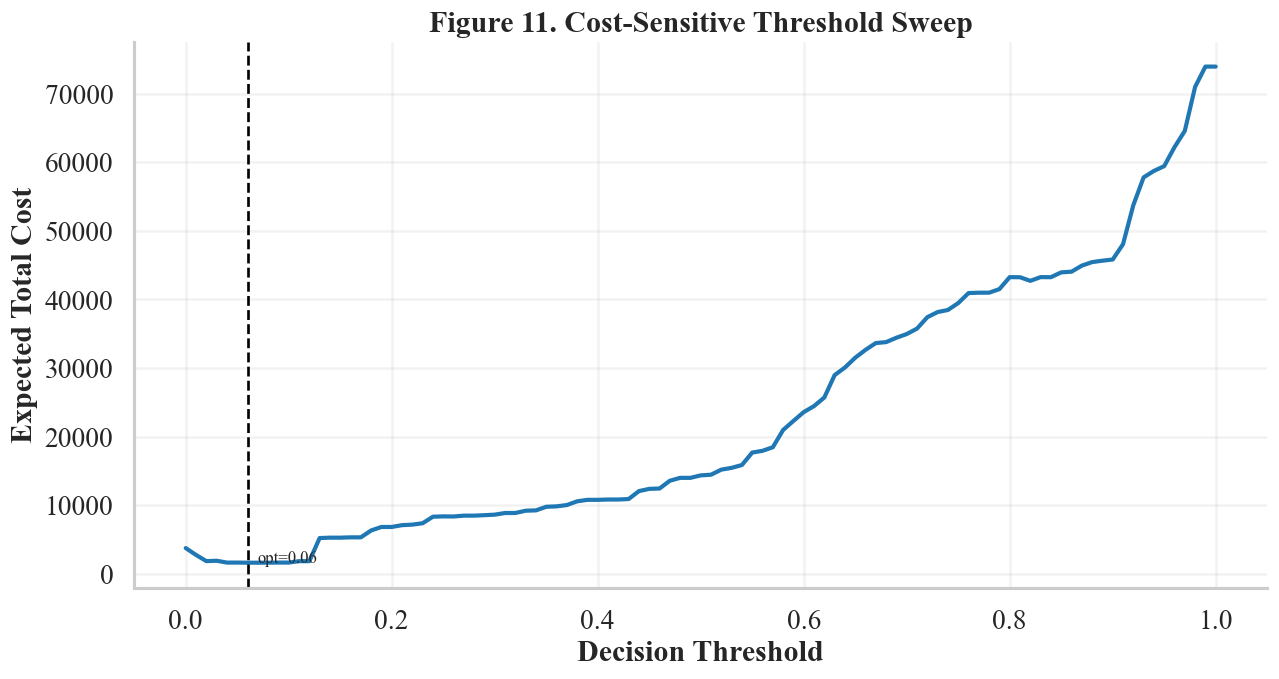

In [13]:
from src.eval.notebook_utils import plot_cost_threshold_curve
plot_cost_threshold_curve(ctx, FIG_DIR, fig_no=11)

**Key Takeaway:** This visual shows where expected intervention + missed-cancellation cost is minimized, supporting operational threshold selection.

## Roadmap Output Snapshot

In [14]:
from src.eval.notebook_utils import roadmap_status_table, late_window_metrics_table, hypothesis_mapping_table

roadmap_status = roadmap_status_table(ctx)
late_window_metrics = late_window_metrics_table(ctx)
hypothesis_status = hypothesis_mapping_table(ctx)

roadmap_status

,component,status,value,details
0,cost_sensitive_threshold,True,0.060000,decision threshold
1,savings_vs_050,True,12730.050000,expected savings vs default 0.50
2,late_window_cancel_rate,True,0.703704,lead_time <= 3 days
3,hypothesis_mapping,True,NaN,H1-H4 summary present


In [15]:
late_window_metrics

,metric,value
0,n_rows_late_window,27.000000
1,late_window_share,0.036000
2,cancel_rate_overall_test,0.666667
3,cancel_rate_late_window,0.703704


In [16]:
hypothesis_status

,hypothesis,status,statement
0,H1,deferred,"Lead time, deposit type, and previous cancella..."
1,H2,supported,Gradient-boosted trees outperform baseline alt...
2,H3,deferred,Lead time has greatest SHAP importance.
3,H4,supported,Cost-sensitive thresholding lowers expected re...


## Context Alerts

In [17]:
from src.eval.notebook_utils import context_alerts_table
context_alerts_table(ctx)

,severity,message
0,warning,thresholds.json has no cost_sensitive policy; ...


## Figure 12. Per-Risk-Tier Calibration Diagnostics

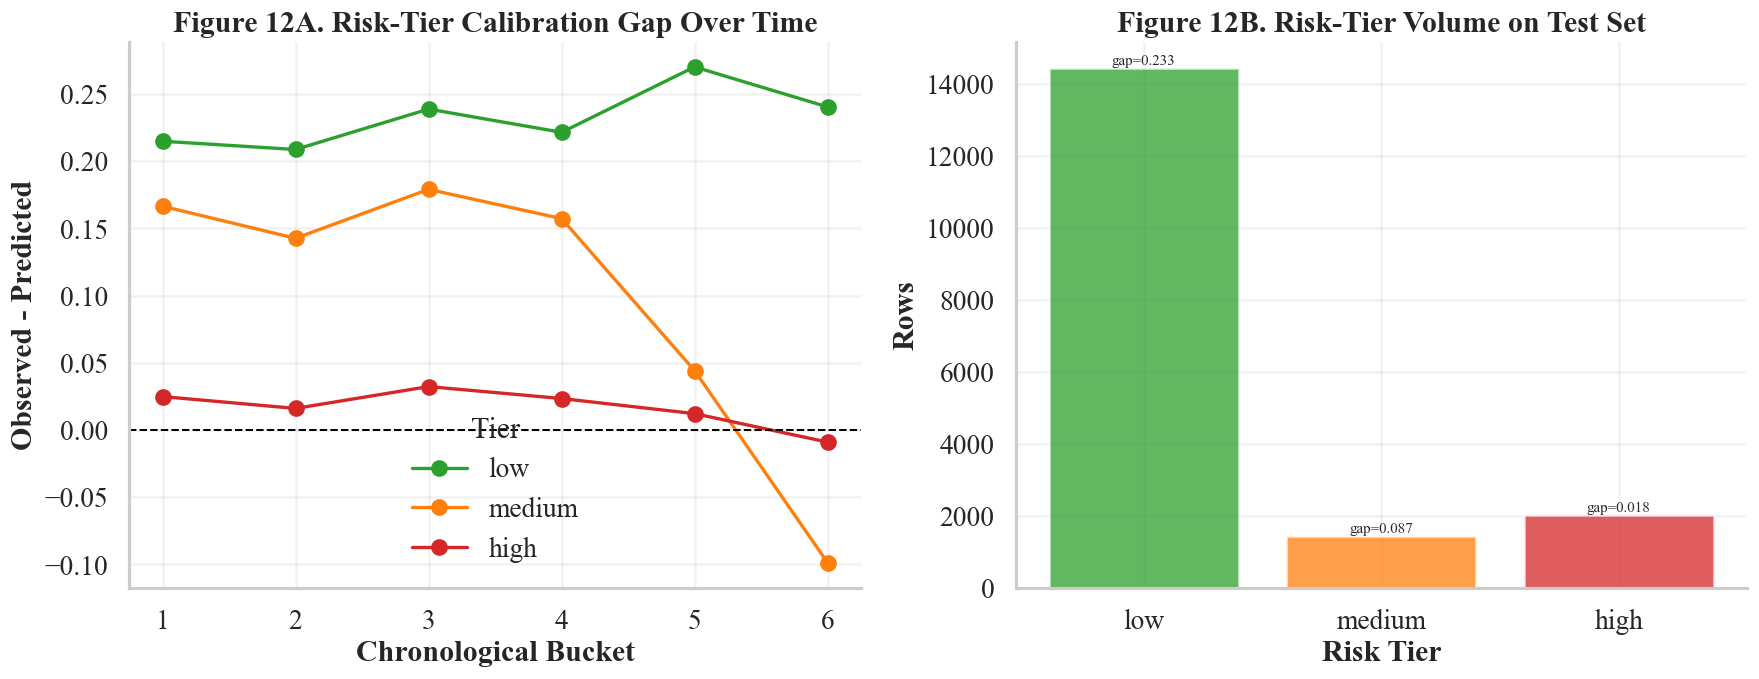

,risk_tier,n_rows,predicted_mean,observed_rate,calibration_gap
0,low,14430,0.063632,0.296743,0.233110
1,medium,1437,0.547039,0.633960,0.086921
2,high,2015,0.903296,0.921092,0.017796


In [18]:
from src.eval.notebook_utils import plot_risk_tier_calibration_over_time

risk_tier_overall, risk_tier_by_time = plot_risk_tier_calibration_over_time(ctx, FIG_DIR, fig_no=12)
risk_tier_overall

In [19]:
risk_tier_by_time.head(20)

,bucket,tier,n_rows,predicted_mean,observed_rate,calibration_gap,date_min,date_max
0,1,low,2328,0.054828,0.269759,0.214932,2017-05-22,2017-06-05
1,1,medium,193,0.553597,0.720207,0.166610,2017-05-22,2017-06-05
2,1,high,460,0.959877,0.984783,0.024905,2017-05-22,2017-06-05
3,2,low,2179,0.062440,0.271225,0.208785,2017-06-05,2017-06-21
4,2,medium,215,0.550327,0.693023,0.142697,2017-06-05,2017-06-21
5,2,high,587,0.958364,0.974446,0.016083,2017-06-05,2017-06-21
6,3,low,2431,0.062658,0.301522,0.238864,2017-06-21,2017-07-08
7,3,medium,234,0.543108,0.722222,0.179114,2017-06-21,2017-07-08
8,3,high,315,0.904169,0.936508,0.032339,2017-06-21,2017-07-08
9,4,low,2554,0.060724,0.282302,0.221578,2017-07-08,2017-07-25


**Key Takeaway:** Tier-level calibration gaps over chronological buckets help validate whether low/medium/high operational bands remain reliable over time.